# Macro Regime Shifts, Sector Earnings Troughs, and Reversal Windows

**Goal.** Build the third research book by combining the repo's existing macro regime engine with the cleaned sector earnings panel. The notebook tests three ideas: macro regime shifts tend to arrive after earnings breadth deteriorates, sector EPS troughs often create tactical reversal windows, and the best reversals happen when macro conditions normalize alongside earnings. This revision also adds a direct lead/lag study and a small quarterly ML screen for regime detection.

**Research questions**
1. Which macro regimes consistently line up with strong or weak sector earnings breadth?
2. Does earnings breadth lead macro improvement, or mostly confirm it after the fact?
3. Which sectors are most sensitive to macro balance, and which sectors feed back most into the next macro move?
4. Can a small quarterly ML model detect regime changes, benign states, or broad macro improvement from lagged earnings and sector context?
5. When sector EPS growth hits a local trough, how often do earnings, macro balance, and sector relative returns improve over the next two quarters?

**Notebook map**
1. Setup and report loading
2. Regime scorecard
3. Earnings breadth through time
4. Lead/lag and sector sensitivity
5. Regime ML screen
6. Regime transitions and deterioration
7. Sector troughs and reversal windows
8. Case studies and live implications
9. Conclusions and caveats

## 1. Setup and report loading

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (11.5, 4.8),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESEARCH_DIR = PROJECT_ROOT / 'outputs' / 'sector_macro_regime_research'
print('research dir:', RESEARCH_DIR)

research dir: D:\dev\price_action\outputs\sector_macro_regime_research


In [2]:
with open(RESEARCH_DIR / 'sector_macro_regime_summary.json', encoding='utf-8') as f:
    summary = json.load(f)

macro_quarters = pd.read_csv(RESEARCH_DIR / 'macro_regime_quarterly_history.csv', parse_dates=['quarter_end_month', 'quarter_end_date'])
panel = pd.read_csv(RESEARCH_DIR / 'sector_macro_regime_panel.csv', parse_dates=['quarter_end_date'])
breadth = pd.read_csv(RESEARCH_DIR / 'quarterly_earnings_breadth.csv', parse_dates=['quarter_end_date'])
lead_lag = pd.read_csv(RESEARCH_DIR / 'macro_earnings_lead_lag.csv')
sector_sensitivity = pd.read_csv(RESEARCH_DIR / 'sector_macro_sensitivity.csv')
regime_summary = pd.read_csv(RESEARCH_DIR / 'regime_earnings_summary.csv')
transition_summary = pd.read_csv(RESEARCH_DIR / 'regime_transition_summary.csv')
transition_episodes = pd.read_csv(RESEARCH_DIR / 'regime_transition_episode_table.csv', parse_dates=['quarter_end_date'])
trough_events = pd.read_csv(RESEARCH_DIR / 'sector_earnings_trough_events.csv', parse_dates=['quarter_end_date'])
trough_regime_summary = pd.read_csv(RESEARCH_DIR / 'sector_earnings_trough_regime_summary.csv')
trough_sector_summary = pd.read_csv(RESEARCH_DIR / 'sector_earnings_trough_sector_summary.csv')
regime_ml_metrics = pd.read_csv(RESEARCH_DIR / 'regime_ml_metrics.csv')
regime_ml_feature_importance = pd.read_csv(RESEARCH_DIR / 'regime_ml_feature_importance.csv')
regime_ml_validation_predictions = pd.read_csv(RESEARCH_DIR / 'regime_ml_validation_predictions.csv', parse_dates=['quarter_end_date'])
regime_ml_holdout_predictions = pd.read_csv(RESEARCH_DIR / 'regime_ml_holdout_predictions.csv', parse_dates=['quarter_end_date'])

regime_scorecard = regime_summary.loc[regime_summary['group_type'] == 'regime'].copy()
regime_scorecard = regime_scorecard.sort_values('macro_balance_score', ascending=False).reset_index(drop=True)
transition_summary['transition'] = transition_summary['prior_regime_label'] + ' -> ' + transition_summary['quarter_end_regime_label']

print('quarters      :', summary['quarter_count'])
print('panel rows    :', summary['panel_rows'])
print('sectors       :', summary['sector_count'])
print('transitions   :', summary['regime_transition_count'])
print('trough events :', summary['trough_event_count'])
print('current regime:', summary['current_regime'])

quarters      : 81
panel rows    : 771
sectors       : 11
transitions   : 32
trough events : 88
current regime: Fragile Late-Cycle Watch


## 2. Regime scorecard

The macro engine already compresses growth, inflation, and stress into named regimes. This section asks whether those regimes also separate strong sector earnings environments from weak ones.

In [3]:
headline = pd.DataFrame({
    'metric': ['current regime', 'quarters', 'sector-quarter rows', 'regime transitions', 'trough events'],
    'value': [
        summary['current_regime'],
        summary['quarter_count'],
        summary['panel_rows'],
        summary['regime_transition_count'],
        summary['trough_event_count'],
    ],
})
display(headline)

display(
    regime_scorecard[[
        'group_label',
        'macro_balance_score',
        'median_eps_growth',
        'negative_eps_growth_share',
        'mean_next_q_excess_return',
        'hit_rate_next_q',
    ]].round(3)
)

,metric,value
0,current regime,Fragile Late-Cycle Watch
1,quarters,81
2,sector-quarter rows,771
3,regime transitions,32
4,trough events,88


,group_label,macro_balance_score,median_eps_growth,negative_eps_growth_share,mean_next_q_excess_return,hit_rate_next_q
0,Disinflationary Growth,0.678,16.811,0.123,0.001,0.494
1,Sideways Low-Volatility Regime,0.231,11.269,0.143,-0.007,0.536
2,Liquidity Bubble Or Valuation Stretch,-0.013,17.144,0.126,-0.012,0.415
3,Fragile Late-Cycle Watch,-0.197,11.814,0.278,0.002,0.508
4,Inflationary Boom,-0.228,21.583,0.107,-0.002,0.492
5,Rate-Shock Regime,-1.729,12.813,0.273,-0.001,0.424
6,Credit Deleveraging,-2.367,1.422,0.472,-0.000,0.444
7,Panic Or Forced Liquidation,-5.443,-21.968,0.778,0.003,0.778


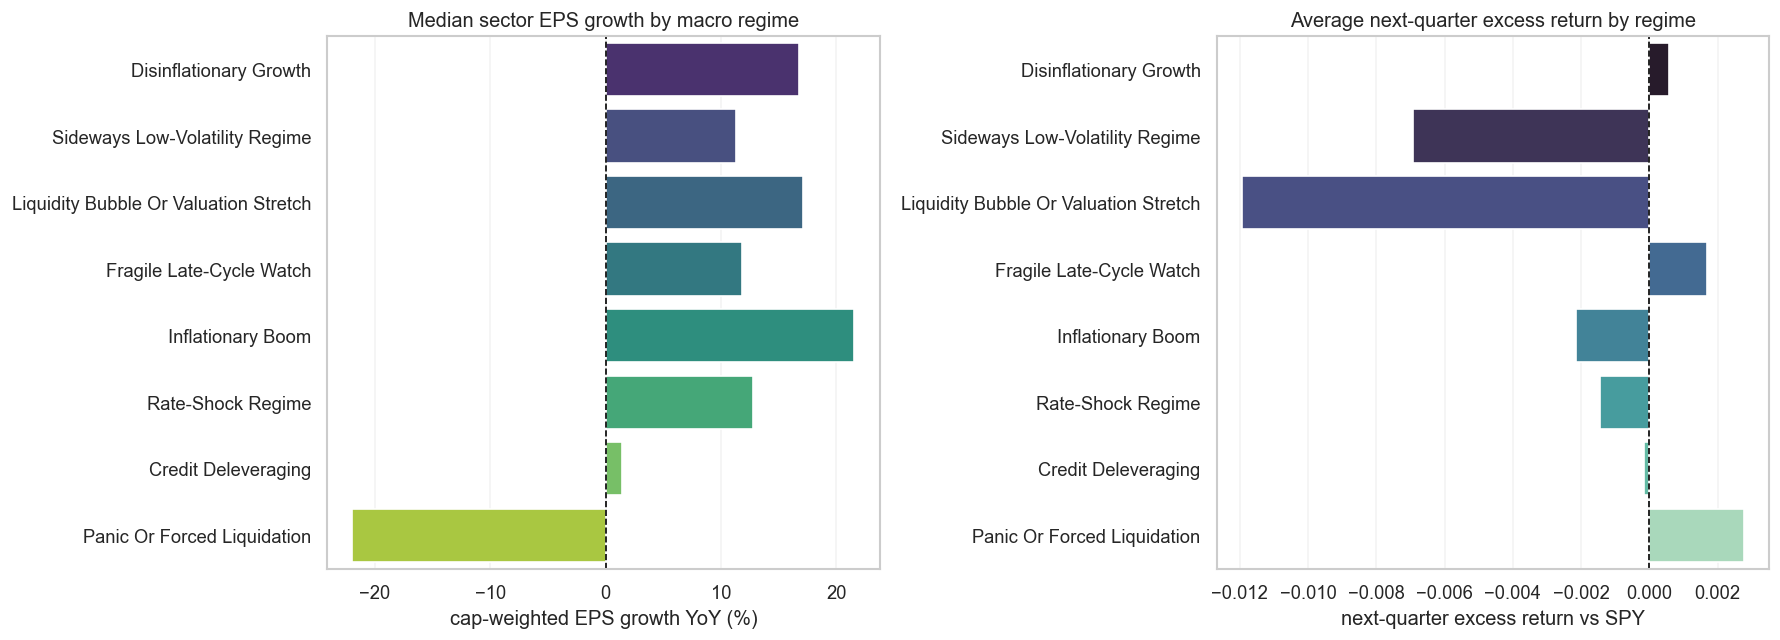

In [4]:
plot_frame = regime_scorecard.copy()
order = plot_frame['group_label'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.barplot(
    data=plot_frame,
    y='group_label',
    x='median_eps_growth',
    hue='group_label',
    order=order,
    dodge=False,
    palette='viridis',
    legend=False,
    ax=axes[0],
)
axes[0].axvline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Median sector EPS growth by macro regime')
axes[0].set_xlabel('cap-weighted EPS growth YoY (%)')
axes[0].set_ylabel('')

sns.barplot(
    data=plot_frame,
    y='group_label',
    x='mean_next_q_excess_return',
    hue='group_label',
    order=order,
    dodge=False,
    palette='mako',
    legend=False,
    ax=axes[1],
)
axes[1].axvline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_title('Average next-quarter excess return by regime')
axes[1].set_xlabel('next-quarter excess return vs SPY')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Earnings breadth through time

The regime labels are easier to trust when they line up with broad deterioration or repair in sector earnings. Here we track the quarterly median EPS-growth line, the share of sectors with negative EPS growth, and the macro balance score.

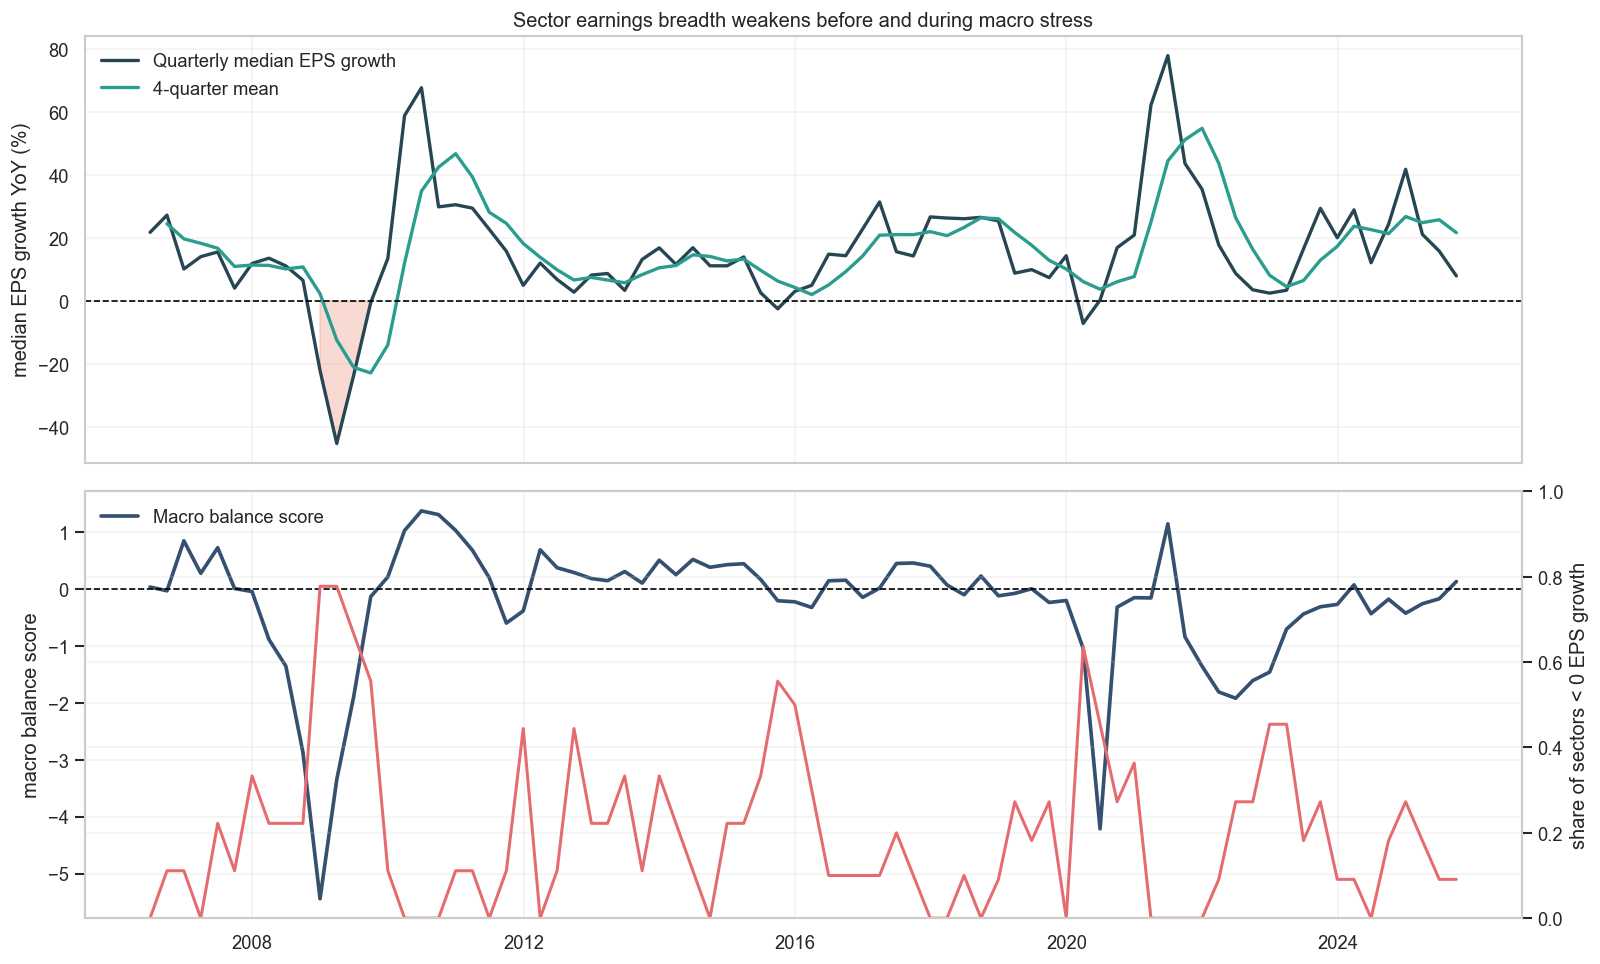

In [5]:
breadth_plot = breadth.copy()
breadth_plot['median_eps_growth_4q'] = breadth_plot['median_eps_growth'].rolling(4, min_periods=2).mean()

fig, axes = plt.subplots(2, 1, figsize=(13.5, 8.2), sharex=True)
axes[0].plot(breadth_plot['quarter_end_date'], breadth_plot['median_eps_growth'], color='#264653', linewidth=2.0, label='Quarterly median EPS growth')
axes[0].plot(breadth_plot['quarter_end_date'], breadth_plot['median_eps_growth_4q'], color='#2a9d8f', linewidth=2.0, label='4-quarter mean')
axes[0].fill_between(
    breadth_plot['quarter_end_date'],
    0.0,
    breadth_plot['median_eps_growth'],
    where=breadth_plot['median_eps_growth'] < 0.0,
    color='#e76f51',
    alpha=0.25,
)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Sector earnings breadth weakens before and during macro stress')
axes[0].set_ylabel('median EPS growth YoY (%)')
axes[0].legend(frameon=False, loc='upper left')

axes[1].plot(breadth_plot['quarter_end_date'], breadth_plot['macro_balance_score'], color='#355070', linewidth=2.2, label='Macro balance score')
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_ylabel('macro balance score')
axes[1].legend(frameon=False, loc='upper left')

ax_right = axes[1].twinx()
ax_right.plot(breadth_plot['quarter_end_date'], breadth_plot['negative_eps_growth_share'], color='#e56b6f', linewidth=1.8, label='Negative EPS-growth share')
ax_right.set_ylabel('share of sectors < 0 EPS growth')
ax_right.set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

In [6]:
worst_quarters = breadth.nsmallest(12, 'median_eps_growth')[
    ['fiscal_quarter', 'regime_label', 'median_eps_growth', 'negative_eps_growth_share', 'mean_next_q_excess_return']
]
display(worst_quarters.round(3))

,fiscal_quarter,regime_label,median_eps_growth,negative_eps_growth_share,mean_next_q_excess_return
11,2009Q1,Credit Deleveraging,-45.129,0.778,0.005
12,2009Q2,Credit Deleveraging,-23.486,0.667,0.003
10,2008Q4,Panic Or Forced Liquidation,-21.968,0.778,0.003
55,2020Q1,Fragile Late-Cycle Watch,-7.010,0.636,-0.013
37,2015Q3,Fragile Late-Cycle Watch,-2.385,0.556,-0.010
13,2009Q3,Fragile Late-Cycle Watch,-0.363,0.556,0.002
56,2020Q2,Fragile Late-Cycle Watch,0.364,0.455,-0.025
66,2022Q4,Rate-Shock Regime,2.594,0.455,-0.027
36,2015Q2,Fragile Late-Cycle Watch,2.716,0.333,-0.004
25,2012Q3,Fragile Late-Cycle Watch,2.895,0.444,0.007


## 4. Lead/lag and sector sensitivity

Positive lead quarters mean the source series leads the target by that many quarters. Negative lead quarters mean the source mostly trails and confirms a move that has already started. This section also checks which sectors respond most to macro balance and which sectors appear most connected to the next macro balance change.

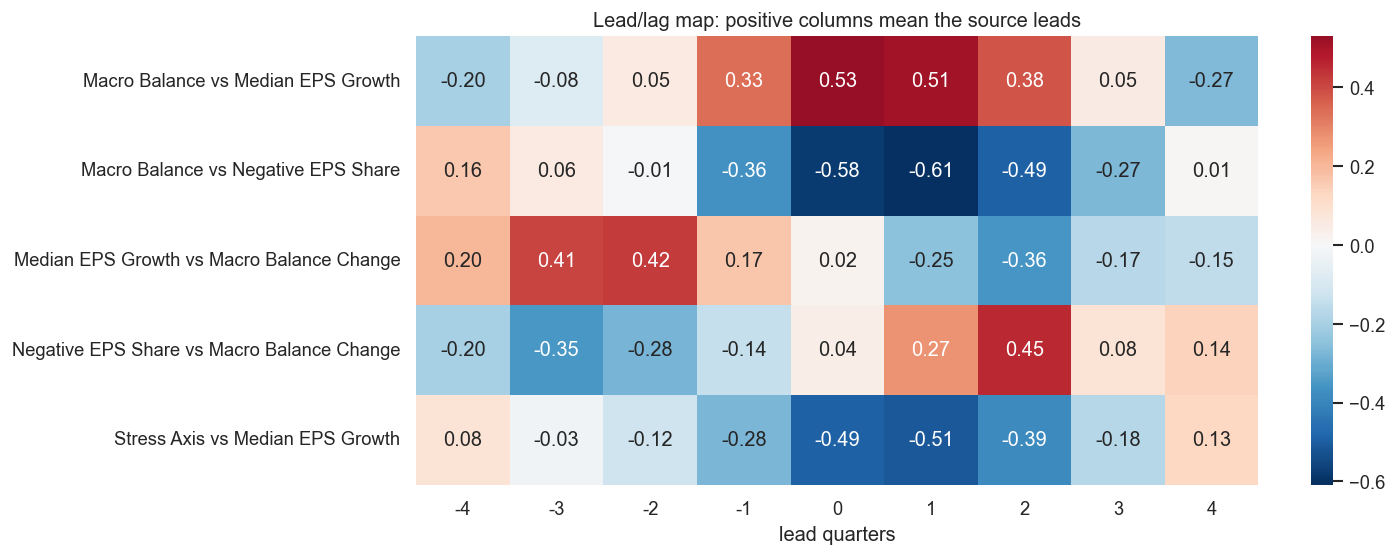

,relationship_label,lead_quarters,correlation,observation_count
14,Macro Balance vs Negative EPS Share,1,-0.608,77
50,Stress Axis vs Median EPS Growth,1,-0.513,77
5,Macro Balance vs Median EPS Growth,1,0.511,77
15,Macro Balance vs Negative EPS Share,2,-0.494,76
42,Negative EPS Share vs Macro Balance Change,2,0.454,78
51,Stress Axis vs Median EPS Growth,2,-0.386,76
6,Macro Balance vs Median EPS Growth,2,0.379,76
24,Median EPS Growth vs Macro Balance Change,2,-0.356,78
32,Median Surprise vs Macro Balance Change,1,0.331,78
41,Negative EPS Share vs Macro Balance Change,1,0.272,78


In [7]:
lead_lag_focus = lead_lag.loc[
    lead_lag['relationship_label'].isin([
        'Median EPS Growth vs Macro Balance Change',
        'Negative EPS Share vs Macro Balance Change',
        'Macro Balance vs Median EPS Growth',
        'Macro Balance vs Negative EPS Share',
        'Stress Axis vs Median EPS Growth',
    ])
].copy()
heatmap = lead_lag_focus.pivot(index='relationship_label', columns='lead_quarters', values='correlation')
fig, ax = plt.subplots(figsize=(12.5, 4.8))
sns.heatmap(heatmap, annot=True, fmt='.2f', cmap='RdBu_r', center=0.0, ax=ax)
ax.set_title('Lead/lag map: positive columns mean the source leads')
ax.set_xlabel('lead quarters')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

display(
    lead_lag.loc[lead_lag['lead_quarters'] > 0]
    .sort_values(['abs_correlation', 'lead_quarters'], ascending=[False, True])
    .head(12)[['relationship_label', 'lead_quarters', 'correlation', 'observation_count']]
    .round(3)
)

,sector,macro_to_next_excess_corr,macro_to_current_eps_growth_corr,earnings_to_next_macro_change_corr,earnings_to_next_excess_corr,quarter_count
0,TECHNOLOGY,-0.202,0.398,-0.152,-0.171,78
1,MATERIALS,-0.139,0.405,-0.189,-0.099,78
2,REAL ESTATE,0.139,0.201,-0.367,0.187,40
3,COMMUNICATION SERVICES,0.120,0.491,-0.220,-0.070,29
4,CONSUMER DISCRETIONARY,-0.097,0.318,-0.043,-0.105,78
5,FINANCIALS,0.085,0.655,-0.169,0.122,78
6,CONSUMER STAPLES,-0.064,0.212,-0.068,-0.102,78
7,UTILITIES,0.045,0.128,0.058,0.002,78
8,ENERGY,0.040,0.031,-0.254,0.157,78
9,INDUSTRIALS,0.032,0.590,-0.382,-0.203,78


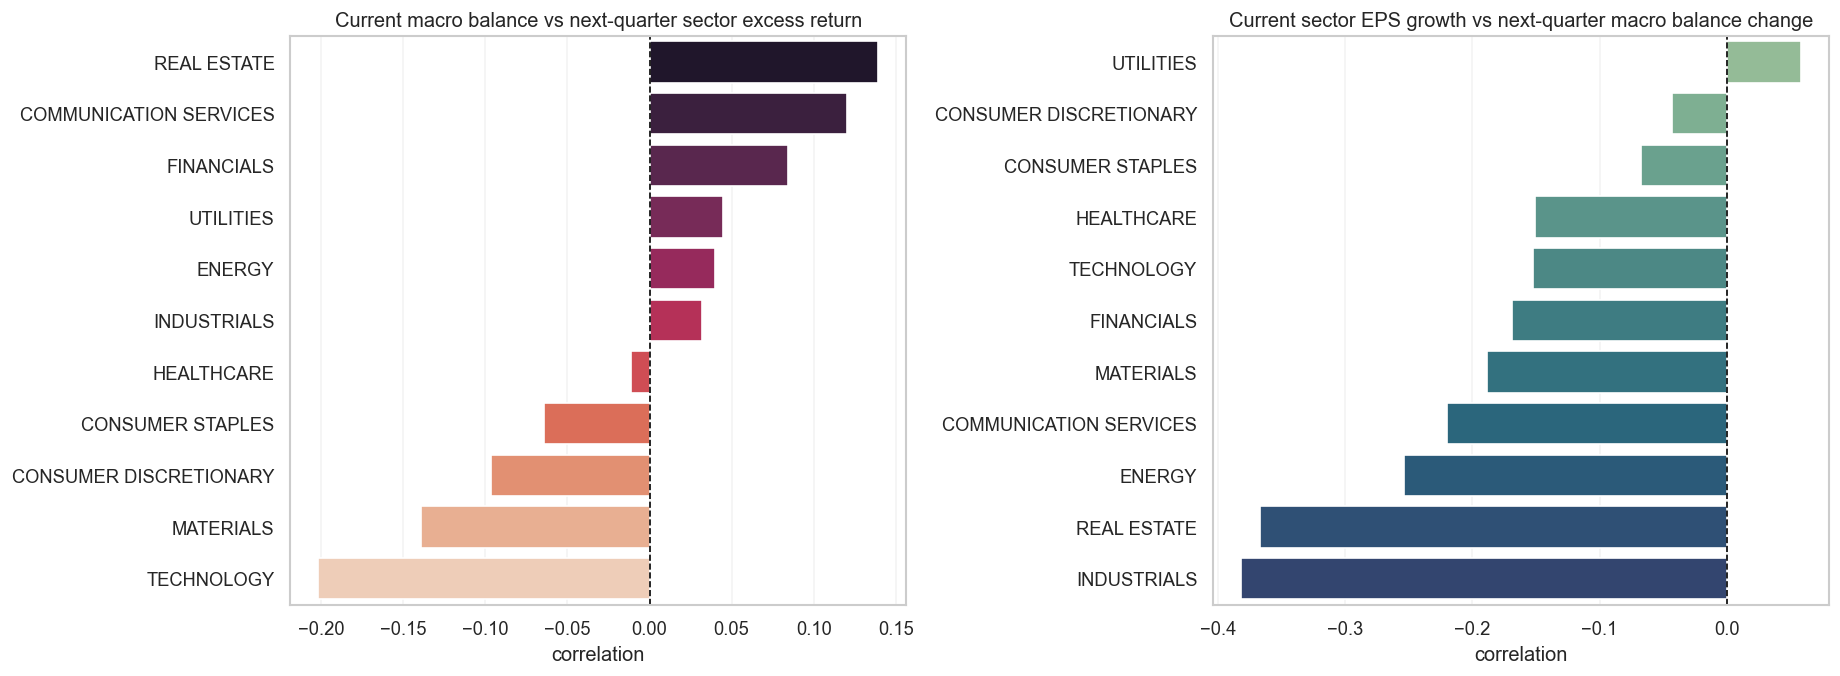

In [8]:
sector_view = sector_sensitivity[[
    'sector',
    'macro_to_next_excess_corr',
    'macro_to_current_eps_growth_corr',
    'earnings_to_next_macro_change_corr',
    'earnings_to_next_excess_corr',
    'quarter_count',
]].copy()
display(sector_view.round(3))

plot_macro = sector_sensitivity.sort_values('macro_to_next_excess_corr', ascending=False).copy()
plot_feedback = sector_sensitivity.sort_values('earnings_to_next_macro_change_corr', ascending=False).copy()
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))
sns.barplot(
    data=plot_macro,
    y='sector',
    x='macro_to_next_excess_corr',
    hue='sector',
    dodge=False,
    palette='rocket',
    legend=False,
    ax=axes[0],
)
axes[0].axvline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Current macro balance vs next-quarter sector excess return')
axes[0].set_xlabel('correlation')
axes[0].set_ylabel('')

sns.barplot(
    data=plot_feedback,
    y='sector',
    x='earnings_to_next_macro_change_corr',
    hue='sector',
    dodge=False,
    palette='crest',
    legend=False,
    ax=axes[1],
)
axes[1].axvline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_title('Current sector EPS growth vs next-quarter macro balance change')
axes[1].set_xlabel('correlation')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Regime ML screen

This is a small quarterly ML exercise, not a production regime engine. The point is to test whether lagged earnings breadth plus cross-sector context can detect exact label flips, broader macro improvement, or benign-state conditions. If exact regime-change labels stay noisy but improvement-state targets hold up, the right use is a regime-risk score rather than a label oracle.

,target_label,model_label,sample_count,positive_rate,roc_auc,precision,recall
25,Current Regime Is Benign,Extra Trees,64,0.312,0.676,0.400,0.800
16,Macro Balance Improves > 0.5 Within Next 2Q,Elastic Net,64,0.188,0.582,0.259,0.583
19,Macro Balance Improves > 0.5 Within Next 2Q,Average Ensemble,64,0.188,0.582,0.259,0.583
9,Shift To Benign Regime Within Next 2Q,Extra Trees,64,0.469,0.577,0.500,0.333
27,Current Regime Is Benign,Average Ensemble,64,0.312,0.576,0.385,0.500
17,Macro Balance Improves > 0.5 Within Next 2Q,Extra Trees,64,0.188,0.575,0.189,0.583
24,Current Regime Is Benign,Elastic Net,64,0.312,0.568,0.385,0.500
26,Current Regime Is Benign,LightGBM / HistGB,64,0.312,0.536,0.312,0.500
11,Shift To Benign Regime Within Next 2Q,Average Ensemble,64,0.469,0.488,0.394,0.433
8,Shift To Benign Regime Within Next 2Q,Elastic Net,64,0.469,0.484,0.394,0.433


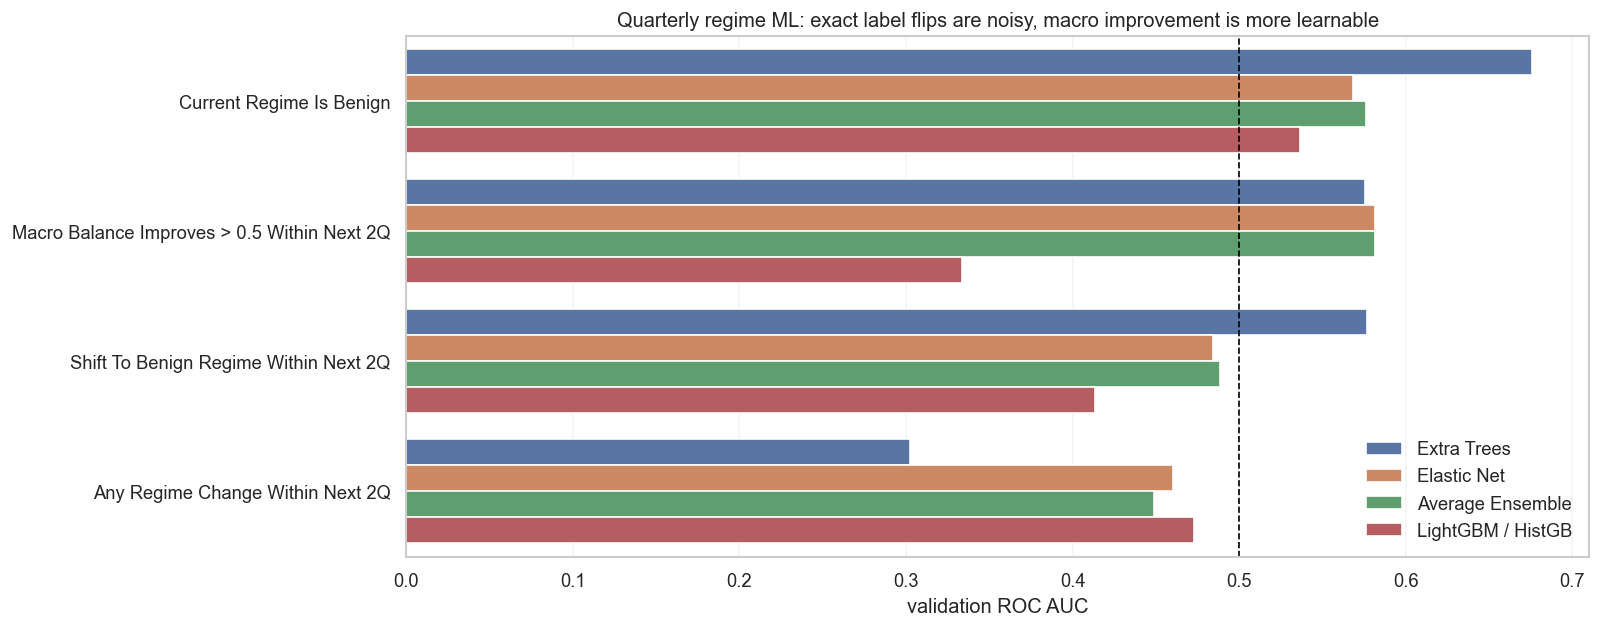

In [9]:
ml_validation = regime_ml_metrics.loc[regime_ml_metrics['scope'] == 'validation'].copy()
ml_validation = ml_validation.sort_values(['roc_auc', 'target_label'], ascending=[False, True])
display(
    ml_validation[[
        'target_label',
        'model_label',
        'sample_count',
        'positive_rate',
        'roc_auc',
        'precision',
        'recall',
    ]].round(3)
)

fig, ax = plt.subplots(figsize=(13.5, 5.4))
sns.barplot(
    data=ml_validation,
    y='target_label',
    x='roc_auc',
    hue='model_label',
    ax=ax,
)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Quarterly regime ML: exact label flips are noisy, macro improvement is more learnable')
ax.set_xlabel('validation ROC AUC')
ax.set_ylabel('')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.show()

,target_label,feature,importance
0,Any Regime Change Within Next 2Q,median_eps_growth_chg2,0.031
1,Any Regime Change Within Next 2Q,eps_growth_spread_lag2,0.025
2,Any Regime Change Within Next 2Q,relative_ret_1y_median_lag2,0.023
3,Any Regime Change Within Next 2Q,surprise_spread,0.023
4,Any Regime Change Within Next 2Q,relative_ret_2q_median_chg2,0.023
5,Any Regime Change Within Next 2Q,inflation_axis_lag2,0.019
6,Any Regime Change Within Next 2Q,eps_growth_spread_chg1,0.018
7,Any Regime Change Within Next 2Q,median_surprise_lag1,0.017
8,Any Regime Change Within Next 2Q,surprise_spread_lag4,0.017
9,Any Regime Change Within Next 2Q,relative_ret_1y_median,0.016


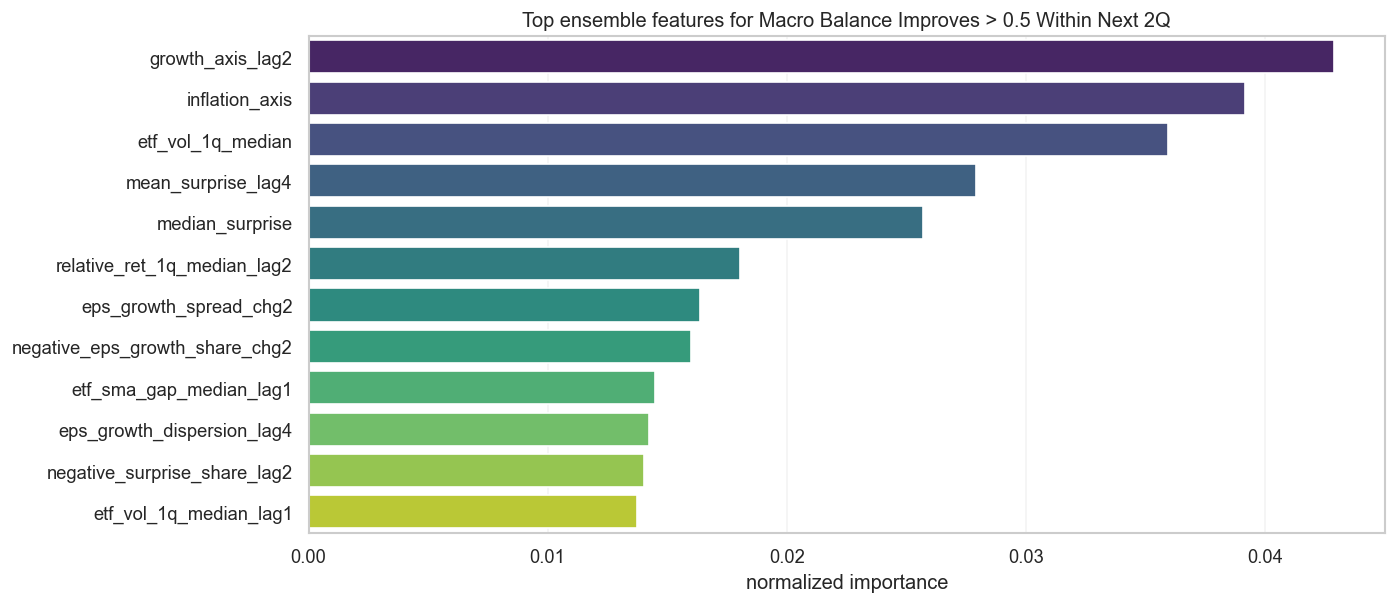

,target_label,fiscal_quarter,quarter_end_regime_label,actual_target,ensemble_probability,macro_balance_score,median_eps_growth,negative_eps_growth_share
68,Current Regime Is Benign,2026Q2,Fragile Late-Cycle Watch,0,0.446,-0.822,NaN,NaN
67,Current Regime Is Benign,2026Q1,Liquidity Bubble Or Valuation Stretch,0,0.599,-0.180,NaN,NaN
66,Current Regime Is Benign,2025Q4,Liquidity Bubble Or Valuation Stretch,0,0.479,-0.031,NaN,NaN
65,Current Regime Is Benign,2025Q3,Liquidity Bubble Or Valuation Stretch,0,0.389,0.132,8.063,0.091
64,Current Regime Is Benign,2025Q2,Liquidity Bubble Or Valuation Stretch,0,0.648,-0.171,15.924,0.091
63,Current Regime Is Benign,2025Q1,Liquidity Bubble Or Valuation Stretch,0,0.336,-0.259,21.262,0.182
62,Current Regime Is Benign,2024Q4,Liquidity Bubble Or Valuation Stretch,0,0.661,-0.425,41.905,0.273
61,Current Regime Is Benign,2024Q3,Liquidity Bubble Or Valuation Stretch,0,0.352,-0.178,24.455,0.182
60,Current Regime Is Benign,2024Q2,Inflationary Boom,1,0.617,-0.434,12.245,0.000
59,Current Regime Is Benign,2024Q1,Inflationary Boom,1,0.659,0.074,29.020,0.091


In [10]:
focus_targets = [
    'Macro Balance Improves > 0.5 Within Next 2Q',
    'Current Regime Is Benign',
    'Any Regime Change Within Next 2Q',
]
feature_view = regime_ml_feature_importance.loc[
    (regime_ml_feature_importance['model_label'] == 'Average Ensemble')
    & (regime_ml_feature_importance['target_label'].isin(focus_targets))
].copy()
display(
    feature_view.groupby('target_label').head(10)[['target_label', 'feature', 'importance']].round(4)
)

best_target = (
    ml_validation.sort_values('roc_auc', ascending=False)
    .loc[ml_validation['model_label'] == 'Average Ensemble']
    .iloc[0]
)
best_target_key = best_target['target_key']
best_target_label = best_target['target_label']
best_features = regime_ml_feature_importance.loc[
    (regime_ml_feature_importance['target_key'] == best_target_key)
    & (regime_ml_feature_importance['model_label'] == 'Average Ensemble')
].head(12).copy()
fig, ax = plt.subplots(figsize=(11.8, 5.2))
sns.barplot(
    data=best_features,
    y='feature',
    x='importance',
    hue='feature',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax,
)
ax.set_title(f'Top ensemble features for {best_target_label}')
ax.set_xlabel('normalized importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

recent_holdout = regime_ml_holdout_predictions.loc[
    regime_ml_holdout_predictions['target_key'].isin(['macro_improves_next_window', 'current_regime_is_benign'])
].copy()
display(
    recent_holdout.sort_values(['target_label', 'quarter_end_date'], ascending=[True, False]).head(12)[[
        'target_label',
        'fiscal_quarter',
        'quarter_end_regime_label',
        'actual_target',
        'ensemble_probability',
        'macro_balance_score',
        'median_eps_growth',
        'negative_eps_growth_share',
    ]].round(3)
)

## 6. Regime transitions and deterioration

The transition tables look at what earnings breadth looked like going into a new regime. If the user's thesis is right, the weakest transitions should show lower entry EPS growth and a higher share of sectors already in negative growth.

,transition,transition_count,avg_entry_macro_balance_score,avg_entry_median_eps_growth,avg_next_median_eps_growth,earnings_rebound_next_q_rate,breadth_rebound_next_q_rate
0,Disinflationary Growth -> Fragile Late-Cycle W...,4,0.434,12.152,14.326,0.750,0.250
1,Fragile Late-Cycle Watch -> Disinflationary Gr...,4,0.686,26.271,24.430,0.250,0.500
2,Inflationary Boom -> Liquidity Bubble Or Valua...,3,0.051,21.900,21.747,0.333,0.333
3,Liquidity Bubble Or Valuation Stretch -> Fragi...,2,-0.560,0.965,5.210,1.000,1.000
4,Rate-Shock Regime -> Inflationary Boom,2,-1.156,3.584,9.600,0.500,0.500
5,Sideways Low-Volatility Regime -> Fragile Late...,2,0.218,5.859,5.901,0.500,0.500
6,Inflationary Boom -> Rate-Shock Regime,2,-1.634,10.247,6.184,0.500,0.000
7,Fragile Late-Cycle Watch -> Sideways Low-Volat...,2,0.165,11.657,11.648,0.500,0.000
8,Liquidity Bubble Or Valuation Stretch -> Infla...,2,-0.043,28.873,21.194,0.500,0.500
9,Panic Or Forced Liquidation -> Credit Delevera...,1,-3.349,-45.129,-23.486,1.000,1.000


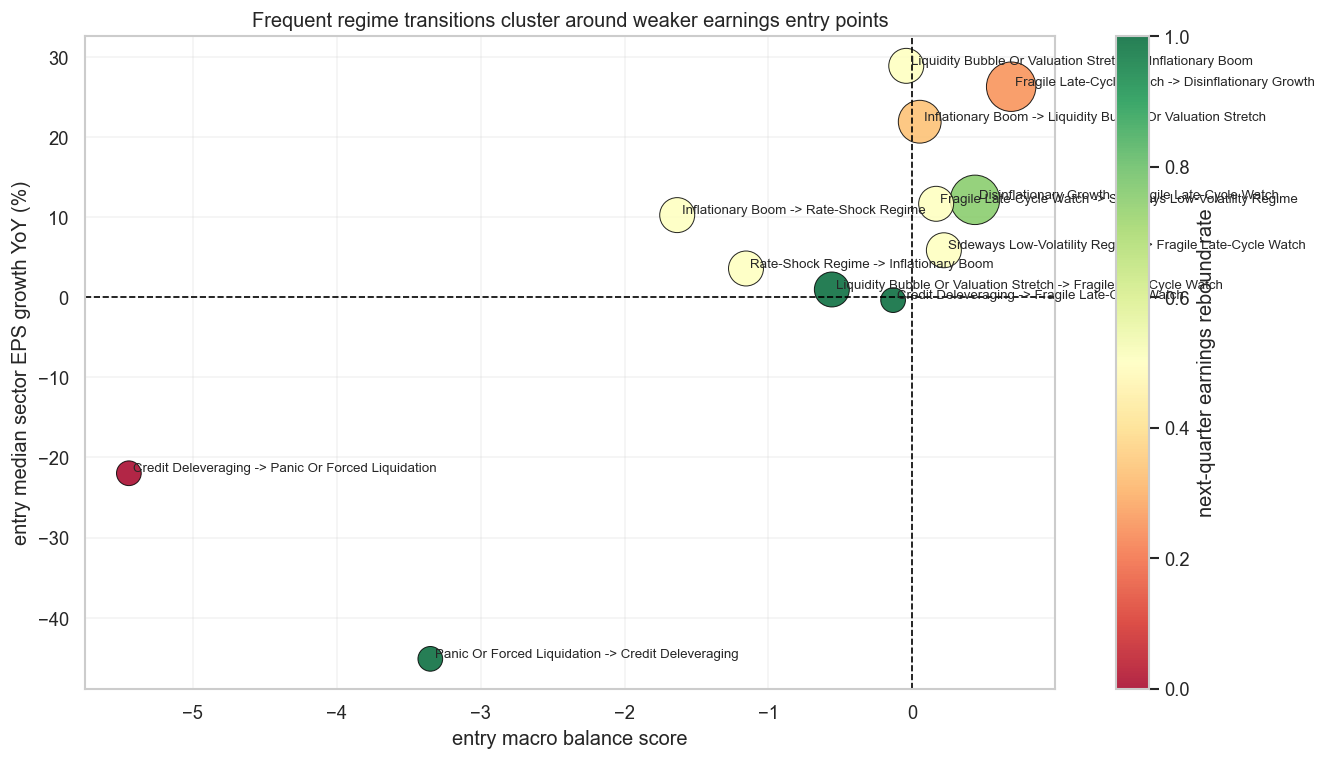

In [11]:
plot_transitions = transition_summary.sort_values(
    ['transition_count', 'avg_entry_median_eps_growth'],
    ascending=[False, True],
).head(12).copy()
display(plot_transitions[[
    'transition',
    'transition_count',
    'avg_entry_macro_balance_score',
    'avg_entry_median_eps_growth',
    'avg_next_median_eps_growth',
    'earnings_rebound_next_q_rate',
    'breadth_rebound_next_q_rate',
]].round(3))

fig, ax = plt.subplots(figsize=(11.5, 6.5))
scatter = ax.scatter(
    plot_transitions['avg_entry_macro_balance_score'],
    plot_transitions['avg_entry_median_eps_growth'],
    s=plot_transitions['transition_count'] * 220,
    c=plot_transitions['earnings_rebound_next_q_rate'],
    cmap='RdYlGn',
    edgecolor='black',
    linewidth=0.6,
    alpha=0.85,
)
for _, row in plot_transitions.iterrows():
    ax.text(
        row['avg_entry_macro_balance_score'] + 0.03,
        row['avg_entry_median_eps_growth'] + 0.2,
        row['transition'],
        fontsize=8,
    )
ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Frequent regime transitions cluster around weaker earnings entry points')
ax.set_xlabel('entry macro balance score')
ax.set_ylabel('entry median sector EPS growth YoY (%)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('next-quarter earnings rebound rate')
plt.tight_layout()
plt.show()

In [12]:
display(
    transition_episodes.sort_values('quarter_end_date', ascending=False).head(12)[[
        'fiscal_quarter',
        'prior_regime_label',
        'quarter_end_regime_label',
        'prior_median_eps_growth_1q',
        'median_eps_growth',
        'next_median_eps_growth_1q',
        'negative_eps_growth_share',
        'earnings_rebound_next_q',
        'mean_next_q_excess_return',
    ]].round(3)
)

,fiscal_quarter,prior_regime_label,quarter_end_regime_label,prior_median_eps_growth_1q,median_eps_growth,next_median_eps_growth_1q,negative_eps_growth_share,earnings_rebound_next_q,mean_next_q_excess_return
31,2024Q3,Inflationary Boom,Liquidity Bubble Or Valuation Stretch,12.245,24.455,41.905,0.182,True,-0.038
30,2023Q1,Rate-Shock Regime,Inflationary Boom,2.594,3.522,16.605,0.455,True,-0.034
29,2022Q4,Inflationary Boom,Rate-Shock Regime,3.647,2.594,3.522,0.455,True,-0.027
28,2022Q3,Rate-Shock Regime,Inflationary Boom,8.845,3.647,2.594,0.273,False,0.019
27,2022Q1,Inflationary Boom,Rate-Shock Regime,35.586,17.899,8.845,0.091,False,0.025
26,2021Q2,Fragile Late-Cycle Watch,Inflationary Boom,62.307,77.992,43.774,0.000,False,-0.008
25,2020Q1,Liquidity Bubble Or Valuation Stretch,Fragile Late-Cycle Watch,14.463,-7.010,0.364,0.636,True,-0.013
24,2019Q2,Fragile Late-Cycle Watch,Liquidity Bubble Or Valuation Stretch,8.941,10.056,7.525,0.182,False,0.004
23,2019Q1,Liquidity Bubble Or Valuation Stretch,Fragile Late-Cycle Watch,25.515,8.941,10.056,0.273,True,-0.004
22,2018Q4,Inflationary Boom,Liquidity Bubble Or Valuation Stretch,26.656,25.515,8.941,0.091,False,-0.002


## 7. Sector troughs and reversal windows

A trough event is defined as a sector quarter where cap-weighted EPS growth is the lowest reading in the last four quarters, still negative, and still worsening on a two-quarter delta. That isolates local capitulation points rather than every weak quarter.

In [13]:
display(
    trough_regime_summary[[
        'quarter_end_regime_label',
        'trough_events',
        'avg_trough_eps_growth',
        'eps_rebound_next_2q_rate',
        'eps_normalizes_next_window_rate',
        'macro_shift_to_benign_next_window_rate',
        'avg_two_quarter_excess_return',
    ]].round(3)
)

display(
    trough_sector_summary.head(11)[[
        'sector',
        'trough_events',
        'avg_trough_eps_growth',
        'eps_rebound_next_q_rate',
        'avg_two_quarter_excess_return',
    ]].round(3)
)

,quarter_end_regime_label,trough_events,avg_trough_eps_growth,eps_rebound_next_2q_rate,eps_normalizes_next_window_rate,macro_shift_to_benign_next_window_rate,avg_two_quarter_excess_return
0,Sideways Low-Volatility Regime,2,-62.927,1.000,1.000,0.500,0.032
1,Inflationary Boom,7,-20.328,1.000,0.571,1.000,-0.012
2,Credit Deleveraging,6,-46.399,1.000,0.167,0.000,-0.037
3,Fragile Late-Cycle Watch,35,-21.787,0.914,0.600,0.314,-0.013
4,Liquidity Bubble Or Valuation Stretch,14,-13.228,0.786,0.714,0.071,-0.046
5,Rate-Shock Regime,8,-17.427,0.750,0.500,1.000,-0.003
6,Panic Or Forced Liquidation,7,-43.667,0.571,0.143,0.000,0.019
7,Disinflationary Growth,9,-16.537,0.556,0.444,0.556,-0.019


,sector,trough_events,avg_trough_eps_growth,eps_rebound_next_q_rate,avg_two_quarter_excess_return
0,ENERGY,16,-43.748,0.688,-0.075
1,MATERIALS,13,-24.794,0.769,0.004
2,UTILITIES,10,-16.071,0.700,0.020
3,TECHNOLOGY,8,-13.771,0.625,0.077
4,CONSUMER DISCRETIONARY,8,-24.863,0.750,-0.003
5,CONSUMER STAPLES,8,-7.232,0.750,-0.039
6,FINANCIALS,8,-25.554,0.750,-0.076
7,INDUSTRIALS,6,-24.084,0.667,0.034
8,COMMUNICATION SERVICES,5,-20.207,0.200,-0.002
9,HEALTHCARE,3,-4.414,1.000,0.013


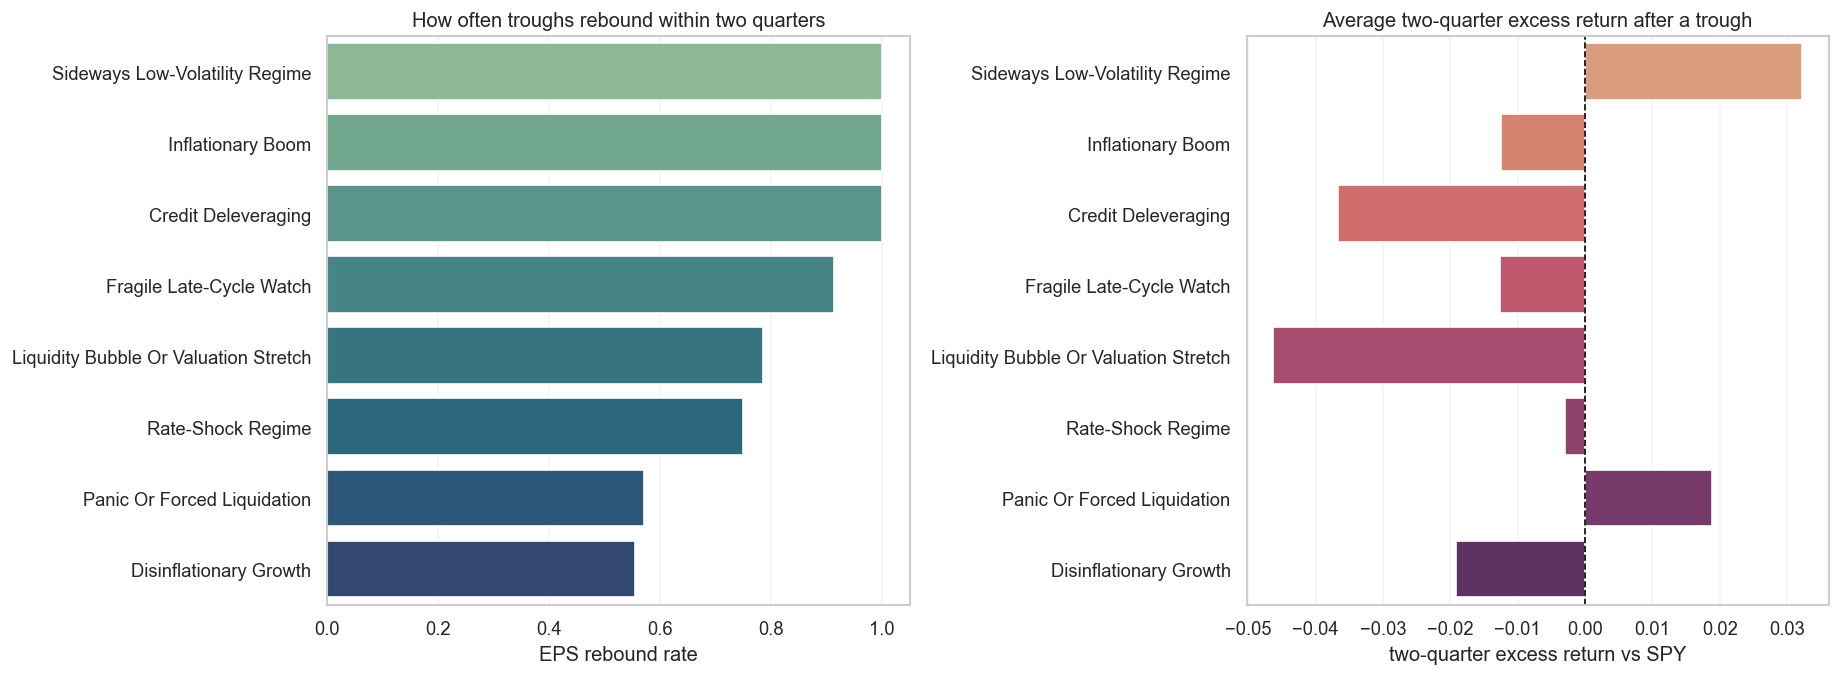

In [14]:
plot_regimes = trough_regime_summary.sort_values('eps_rebound_next_2q_rate', ascending=False).copy()
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))
sns.barplot(
    data=plot_regimes,
    y='quarter_end_regime_label',
    x='eps_rebound_next_2q_rate',
    hue='quarter_end_regime_label',
    dodge=False,
    palette='crest',
    legend=False,
    ax=axes[0],
)
axes[0].set_title('How often troughs rebound within two quarters')
axes[0].set_xlabel('EPS rebound rate')
axes[0].set_ylabel('')

sns.barplot(
    data=plot_regimes,
    y='quarter_end_regime_label',
    x='avg_two_quarter_excess_return',
    hue='quarter_end_regime_label',
    dodge=False,
    palette='flare',
    legend=False,
    ax=axes[1],
)
axes[1].axvline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_title('Average two-quarter excess return after a trough')
axes[1].set_xlabel('two-quarter excess return vs SPY')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

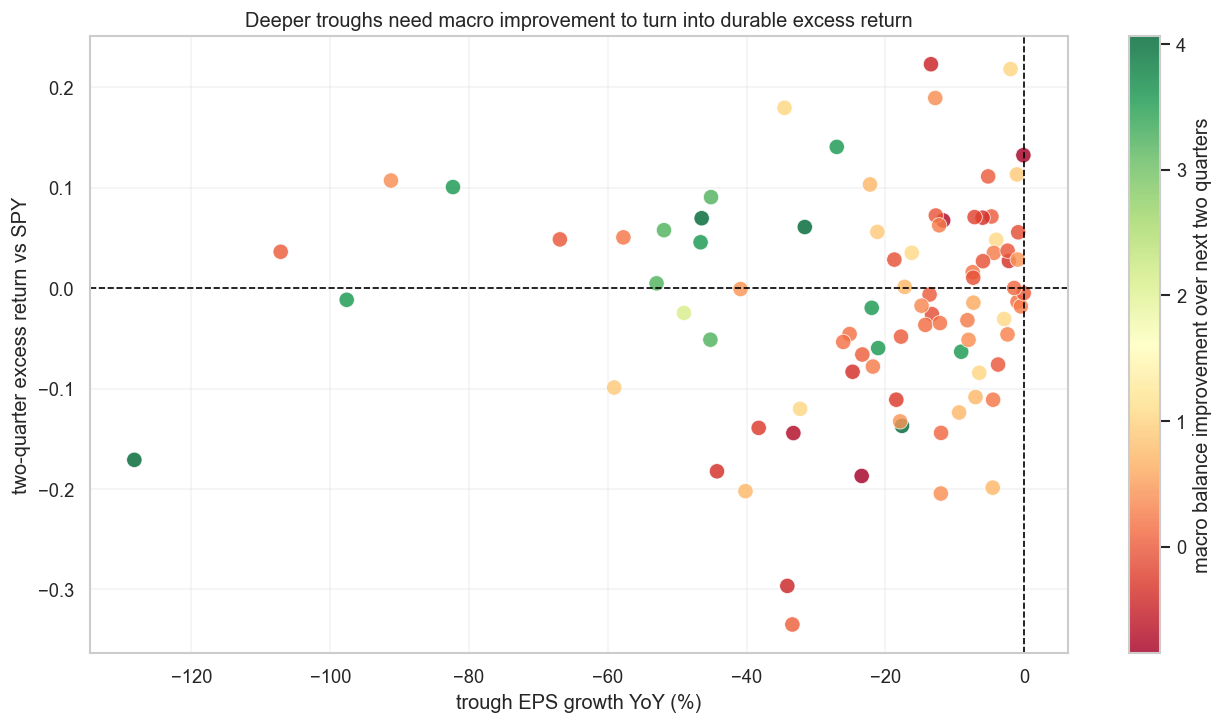

,fiscal_quarter,sector,quarter_end_regime_label,cap_weighted_quarterly_eps_yoy_pct,target_excess_return,two_quarter_excess_return,macro_balance_improvement_next_window,eps_rebound_next_2q,macro_regime_change_next_window
62,2020Q2,ENERGY,Fragile Late-Cycle Watch,-128.234,-0.286,-0.171,4.062,True,False
45,2016Q2,ENERGY,Sideways Low-Volatility Regime,-107.146,0.003,0.036,0.010,True,True
8,2008Q4,FINANCIALS,Panic Or Forced Liquidation,-97.630,-0.177,-0.012,3.550,True,True
43,2015Q4,ENERGY,Fragile Late-Cycle Watch,-91.252,0.020,0.107,0.370,True,True
10,2008Q4,MATERIALS,Panic Or Forced Liquidation,-82.317,0.095,0.101,3.550,True,True
42,2015Q3,MATERIALS,Fragile Late-Cycle Watch,-66.909,0.026,0.048,-0.019,True,False
73,2022Q3,UTILITIES,Inflationary Boom,-59.086,0.009,-0.099,0.905,True,True
26,2013Q2,MATERIALS,Fragile Late-Cycle Watch,-57.758,0.049,0.050,0.198,True,True
15,2009Q1,TECHNOLOGY,Credit Deleveraging,-52.978,0.008,0.005,3.215,True,True
12,2009Q1,CONSUMER DISCRETIONARY,Credit Deleveraging,-51.905,0.017,0.058,3.215,True,True


In [15]:
fig, ax = plt.subplots(figsize=(11.2, 6.2))
scatter = ax.scatter(
    trough_events['cap_weighted_quarterly_eps_yoy_pct'],
    trough_events['two_quarter_excess_return'],
    c=trough_events['macro_balance_improvement_next_window'],
    s=85,
    cmap='RdYlGn',
    alpha=0.82,
    edgecolors='white',
    linewidths=0.5,
)
ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Deeper troughs need macro improvement to turn into durable excess return')
ax.set_xlabel('trough EPS growth YoY (%)')
ax.set_ylabel('two-quarter excess return vs SPY')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('macro balance improvement over next two quarters')
plt.tight_layout()
plt.show()

display(
    trough_events.nsmallest(12, 'cap_weighted_quarterly_eps_yoy_pct')[[
        'fiscal_quarter',
        'sector',
        'quarter_end_regime_label',
        'cap_weighted_quarterly_eps_yoy_pct',
        'target_excess_return',
        'two_quarter_excess_return',
        'macro_balance_improvement_next_window',
        'eps_rebound_next_2q',
        'macro_regime_change_next_window',
    ]].round(3)
)

## 8. Case studies and live implications

The deepest troughs are concentrated in familiar stress episodes. Looking at them directly is useful because the timing problem is not simply about buying the worst print; it is about buying when earnings and macro conditions begin to repair together.

In [16]:
spotlight_quarters = ['2008Q4', '2015Q4', '2020Q2', '2022Q4']
spotlight_events = trough_events.loc[trough_events['fiscal_quarter'].isin(spotlight_quarters)].copy()
spotlight_events = spotlight_events.sort_values(['fiscal_quarter', 'sector'])
display(
    spotlight_events[[
        'fiscal_quarter',
        'sector',
        'quarter_end_regime_label',
        'cap_weighted_quarterly_eps_yoy_pct',
        'target_excess_return',
        'two_quarter_excess_return',
        'macro_balance_improvement_next_window',
        'macro_shift_to_benign_next_window',
    ]].round(3)
)

recent_transitions = transition_episodes.sort_values('quarter_end_date', ascending=False).head(10)
display(
    recent_transitions[[
        'fiscal_quarter',
        'prior_regime_label',
        'quarter_end_regime_label',
        'prior_median_eps_growth_1q',
        'median_eps_growth',
        'next_median_eps_growth_1q',
        'earnings_rebound_next_q',
        'mean_next_q_excess_return',
    ]].round(3)
)

,fiscal_quarter,sector,quarter_end_regime_label,cap_weighted_quarterly_eps_yoy_pct,target_excess_return,two_quarter_excess_return,macro_balance_improvement_next_window,macro_shift_to_benign_next_window
5,2008Q4,CONSUMER DISCRETIONARY,Panic Or Forced Liquidation,-46.633,0.028,0.046,3.550,False
6,2008Q4,CONSUMER STAPLES,Panic Or Forced Liquidation,-9.074,0.002,-0.063,3.550,False
7,2008Q4,ENERGY,Panic Or Forced Liquidation,-21.968,0.006,-0.020,3.550,False
8,2008Q4,FINANCIALS,Panic Or Forced Liquidation,-97.630,-0.177,-0.012,3.550,False
9,2008Q4,INDUSTRIALS,Panic Or Forced Liquidation,-21.039,-0.093,-0.060,3.550,False
10,2008Q4,MATERIALS,Panic Or Forced Liquidation,-82.317,0.095,0.101,3.550,False
11,2008Q4,TECHNOLOGY,Panic Or Forced Liquidation,-27.007,0.131,0.141,3.550,False
43,2015Q4,ENERGY,Fragile Late-Cycle Watch,-91.252,0.020,0.107,0.370,True
44,2015Q4,UTILITIES,Fragile Late-Cycle Watch,-12.815,0.142,0.189,0.370,True
62,2020Q2,ENERGY,Fragile Late-Cycle Watch,-128.234,-0.286,-0.171,4.062,False


,fiscal_quarter,prior_regime_label,quarter_end_regime_label,prior_median_eps_growth_1q,median_eps_growth,next_median_eps_growth_1q,earnings_rebound_next_q,mean_next_q_excess_return
31,2024Q3,Inflationary Boom,Liquidity Bubble Or Valuation Stretch,12.245,24.455,41.905,True,-0.038
30,2023Q1,Rate-Shock Regime,Inflationary Boom,2.594,3.522,16.605,True,-0.034
29,2022Q4,Inflationary Boom,Rate-Shock Regime,3.647,2.594,3.522,True,-0.027
28,2022Q3,Rate-Shock Regime,Inflationary Boom,8.845,3.647,2.594,False,0.019
27,2022Q1,Inflationary Boom,Rate-Shock Regime,35.586,17.899,8.845,False,0.025
26,2021Q2,Fragile Late-Cycle Watch,Inflationary Boom,62.307,77.992,43.774,False,-0.008
25,2020Q1,Liquidity Bubble Or Valuation Stretch,Fragile Late-Cycle Watch,14.463,-7.010,0.364,True,-0.013
24,2019Q2,Fragile Late-Cycle Watch,Liquidity Bubble Or Valuation Stretch,8.941,10.056,7.525,False,0.004
23,2019Q1,Liquidity Bubble Or Valuation Stretch,Fragile Late-Cycle Watch,25.515,8.941,10.056,True,-0.004
22,2018Q4,Inflationary Boom,Liquidity Bubble Or Valuation Stretch,26.656,25.515,8.941,False,-0.002


In [17]:
weakest_regime = regime_scorecard.nsmallest(1, 'median_eps_growth').iloc[0]
best_reversal_regime = trough_regime_summary.sort_values(
    ['eps_rebound_next_2q_rate', 'avg_two_quarter_excess_return'],
    ascending=[False, False],
).iloc[0]
most_common_transition = transition_summary.sort_values('transition_count', ascending=False).iloc[0]

print('Weakest regime by median EPS growth:', weakest_regime['group_label'])
print('  median EPS growth        :', round(float(weakest_regime['median_eps_growth']), 3))
print('  negative EPS-growth share:', round(float(weakest_regime['negative_eps_growth_share']), 3))
print()
print('Best trough-reversal regime:', best_reversal_regime['quarter_end_regime_label'])
print('  EPS rebound rate over next 2Q :', round(float(best_reversal_regime['eps_rebound_next_2q_rate']), 3))
print('  avg 2Q excess return          :', round(float(best_reversal_regime['avg_two_quarter_excess_return']), 3))
print()
print('Most common transition:', most_common_transition['transition'])
print('  transition count             :', int(most_common_transition['transition_count']))
print('  entry median EPS growth      :', round(float(most_common_transition['avg_entry_median_eps_growth']), 3))
print('  next-quarter rebound rate    :', round(float(most_common_transition['earnings_rebound_next_q_rate']), 3))

Weakest regime by median EPS growth: Panic Or Forced Liquidation
  median EPS growth        : -21.968
  negative EPS-growth share: 0.778

Best trough-reversal regime: Sideways Low-Volatility Regime
  EPS rebound rate over next 2Q : 1.0
  avg 2Q excess return          : 0.032

Most common transition: Disinflationary Growth -> Fragile Late-Cycle Watch
  transition count             : 4
  entry median EPS growth      : 12.152
  next-quarter rebound rate    : 0.75


## 9. Conclusions and caveats

**Takeaways**
- The regime engine does separate earnings environments: the weakest macro states carry lower median EPS growth and far more sectors in negative growth.
- The lead/lag map says earnings are not a clean one-quarter regime oracle. Macro balance and sector earnings mostly move together, while the strongest forward-looking signal is broader macro improvement rather than exact label flips.
- The small quarterly ML block can rank macro improvement and benign-state conditions better than it can guess every exact regime change. That is useful, but it argues for a risk score rather than a hard switch model.
- Sector troughs often do rebound in earnings terms, but price follow-through is selective. The better reversal windows are the ones where the macro balance score improves or the regime shifts into a more benign state within the next two quarters.

**Caveats**
- The study uses sector ETF returns as liquid implementation proxies, not direct sector baskets built from every underlying security.
- Trough detection is intentionally simple and rule-based. It is designed for robust screening, not for proving a structural turning-point model.
- Macro regimes are monthly and sector earnings are quarterly, so timing is necessarily coarse. The right operational use is regime-aware ranking and sizing, not precise day-level entry timing.
- The ML sample is only about two decades of quarterly history. Any useful result here should be treated as directional evidence, not as a stable production estimate.